<a href="https://colab.research.google.com/github/matti410/Trading-System-Creator_V4/blob/main/Trading_Grid_Search_v4_backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ricerca di Trading System

Serve a **scoprire se un segnale di ingresso ha un vantaggio reale**, separando entry, uscita e "quando sto fermo" — cercarli insieme confonde quale dei tre sta davvero funzionando.

Si legge dall'alto in basso, senza celle facoltative: ogni sezione usa il risultato di quella prima.

**Ordine:** la Sessione 1 misura il segnale puro (nessun capitale, nessuna posizione). La Sessione 2 sceglie come uscirne e diventa un sistema vero, con trade e costi.

In [ ]:
!pip install -q TA-Lib==0.8.1 backtesting==0.6.6   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 6.9 MB/s eta 0:00:00


### Sezione 0 · Preparazione

Clona la repo e prepara l'ambiente. Va eseguita una volta sola a inizio sessione Colab.

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Creator_V4')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Creator_V4.git

%cd Trading-System-Creator_V4

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Creator_V4'...
remote: Enumerating objects: 283, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 283 (delta 66), reused 0 (delta 0), pack-reused 160 (from 1)
Receiving objects: 100% (283/283), 9.40 MiB | 5.57 MiB/s, done.
Resolving deltas: 100% (146/146), done.
/content/Trading-System-Creator_V4


In [ ]:
import datetime as dt
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta

import entry_long, entry_short
import exit_long, exit_short
import engine as eng
from engine.vwap_ops import vwap_anchored_daily
import engine.event_study
import engine.splitting
from engine.exit_search_bt import run_exit_search_bt
import filter_conditions, vwap_regime_filter_conditions
from engine.filter_search_bt import run_filter_search_bt
from engine.due_meta import due_meta
from engine.equity_plot import plot_equity
from engine.costi import (parametri_backtest, verifica_da_storico_deals,
                          deriva_costo_nel_tempo, spread_corrente)
from engine.giudizio import scheda_strategia, soglia_rumore
from engine.broker_tz_diagnostic import to_utc_index
from engine.quarantena import verifica_indice_utc, quarantena
from engine.sessioni import in_sessione, barre_da_apertura, elenco_sessioni
from entry_metro import registra_trigger_metro, NOMI_METRO
from engine.indicatori import aggiungi_indicatori

/usr/local/lib/python3.13/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Sezione 1 · I dati

Scarica le candele da MetaTrader 5.

**Parametri che puoi cambiare:** strumento, timeframe, periodo storico.

In [ ]:
symbol    = "EURUSD"
timeframe = 'M15'
FREQ      = "15min"      # come pandas scrive il timeframe: "15min", "h", "D"

df = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df = to_utc_index(df, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-18 20:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


### Strato 1-2 — quarantena e sessioni

`verifica_indice_utc` si ferma se l'indice non è UTC vero (difesa contro
l'etichetta fantasma). `quarantena` marca le barre non affidabili: la
finestra del rollover 16:45-18:00 NY, dove i prezzi bid sono deformati
dall'allargamento dello spread, e la prima barra dopo ogni interruzione.

Attese su EURUSD M15: ~5,2% di barre in quarantena. Se la percentuale
è molto diversa, fermati e controlla l'indice prima di proseguire.

In [ ]:
verifica_indice_utc(df)
q = quarantena(df)

display(elenco_sessioni())

[verifica_indice_utc] OK — 97.2% delle 354 riaperture cade domenica 17:00 New York. Barre da 0 days 00:15:00.
[quarantena] 167219 barre esaminate
    rollover                8691  (5.20%)
    dopo_interruzione        357  (0.21%)
    totale                  8695  (5.20%)
    finestra rollover: 16:45-18:00 ora di New York


,fuso,apertura,chiusura,usabile come
sessione,,,,
ROLLOVER,America/New_York,17:00,— (istante),evento
TOKYO,Asia/Tokyo,09:00,18:00,evento + filtro
LONDRA,Europe/London,08:00,17:00,evento + filtro
NEW_YORK,America/New_York,08:00,17:00,evento + filtro
NYSE,America/New_York,09:30,16:00,evento + filtro
FIX_LONDRA,Europe/London,16:00,— (istante),evento


In [ ]:
costi = parametri_backtest(symbol, bars=df, valuta_conto="USD", percentile=75.0, usa_mt5 = False, spread_pips = 0.1,)
costi   # -> {'spread': ..., 'commission': ...}

EURUSD  [forex]  conto in USD
   prezzo mediano   : 1.11191   nozionale: 111,191 USD
   spread           :  0.090 bp   <- listino (0.1 pips) — senza MT5
   commissione      :  0.630 bp   <- 7.00 USD round-turn per lotto
   COSTO ROUND-TURN :  0.719 bp
   -> spread=8.994e-06   commission=3.148e-05   (commission e' PER LATO: round-turn / 2)
   -> in pips: spread 0.100 + commissione 0.700 = 0.800 pips round-turn


{'spread': 8.99353364930615e-06, 'commission': 3.147736777257152e-05}

### Entry-metro — il righello temporale

Cinque ingressi che entrano all'apertura di una sessione e basta, senza
nessuna condizione di prezzo. **Non sono strategie: sono un metro.**

| Metro | Apertura |
|---|---|
| `M_TOKYO` | 09:00 Asia/Tokyo |
| `M_LONDRA` | 08:00 Europe/London |
| `M_NEW_YORK` | 08:00 America/New_York |
| `M_NYSE` | 09:30 America/New_York |
| `M_FIX_LONDRA` | 16:00 Europe/London |

Servono a rispondere a una domanda sola: **il mio pattern di prezzo fa
meglio del semplice entrare a quell'ora?** Un pattern che non batte il
proprio metro non sta aggiungendo informazione di prezzo: sta scegliendo
l'orologio.

#### Come si legge il segno

La curva è `(Close[i+k] / Open[i+1] - 1) × direction`, in percentuale.
Con `direction = +1` (long):

- **valore positivo** → da quell'ora in avanti il prezzo mediamente **sale**
- **valore negativo** → mediamente **scende** (quindi sarebbe uno short)

Due avvertenze che cambiano la lettura:

1. **L'ingresso è alla barra dopo.** Il trigger scatta sulla barra di
   apertura, ma si entra all'apertura della barra successiva — la regola
   anti-lookahead del framework, uguale per tutte le entry. `M_LONDRA`
   misura quindi il movimento dalle **08:15** di Londra, non dalle 08:00.
2. **Conta lo scostamento dalla linea nera del mercato, non l'altezza.**
   Su un asset con deriva la curva grezza sale da sola: guarda
   `vs_mercato_pct`.

#### Cosa NON sono

Se una metro esce con `volte_incertezza` alto, **non è un edge**: è deriva
intraday dell'asset. Le ampiezze sono di 1-2 pips, dentro il rumore dei
costi.

E soprattutto: **non vanno contate fra le prove.** Quando passi `k` a
`soglia_rumore`, passa il numero di entry *vere*, non il numero di righe
della tabella. `NOMI_METRO` serve a escluderle anche dalla ricerca delle
uscite.

[registra_trigger_metro] 5 metro registrate (0 gia' presenti).
    Sono un RIFERIMENTO, non candidati: escludile dal conteggio dei test multipli (k) e dalla ricerca delle uscite. Usa NOMI_METRO.
pip = 0.0001 unita' di prezzo  (prezzo medio 1.12)
  barra   6/48
  barra  12/48
  barra  18/48
  barra  24/48
  barra  30/48
  barra  36/48
  barra  42/48
  barra  48/48

5 entry · orizzonte 48 barre · 8,713 trigger misurati
soglia di rumore per 5 entry × picco su 48 barre (famiglia 5%): |volte_incertezza| > 3.33  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda,oltre_rumore
0,M_FIX_LONDRA,1,1743,24,-1.663016,-0.014884,0.004950,-3.006668,0.005945,-0.015640,24,False,False
1,M_LONDRA,1,1743,19,-1.609480,-0.014404,0.005486,-2.625564,-0.004832,-0.015040,19,False,False
2,M_NYSE,1,1742,30,-1.851925,-0.016574,0.006757,-2.452906,0.004488,-0.017480,30,False,False
3,M_TOKYO,1,1743,47,-1.315430,-0.011772,0.006947,-1.694706,-0.008235,-0.013101,47,True,False
4,M_NEW_YORK,1,1742,36,-1.391976,-0.012458,0.008325,-1.496438,0.007387,-0.013511,36,True,False


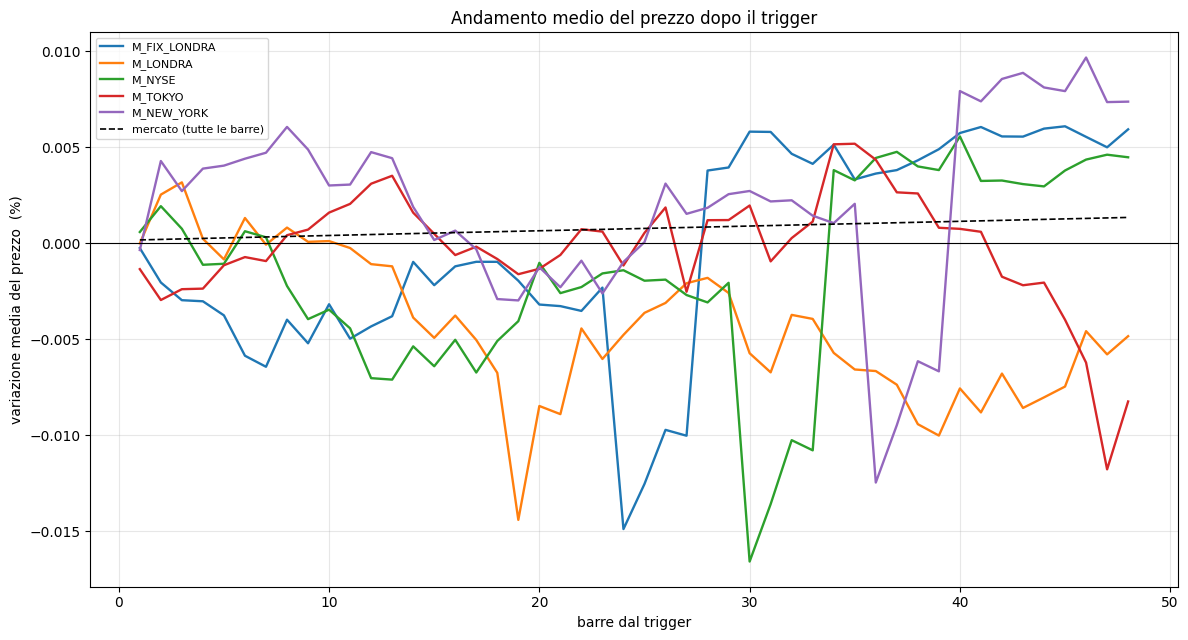

In [ ]:
registra_trigger_metro()

ev_metro = engine.event_study.run_event_study(df, entry_names=list(NOMI_METRO), horizon=48)
display(ev_metro.sintesi)
ev_metro.plot()

## Sezione 2 · Gli indicatori

Le condizioni di ingresso (`entry_long.py`, `entry_short.py`) non calcolano niente da sole: leggono colonne già pronte in questa tabella. Qui le costruiamo.

| Colonna | Cos'è | Chi la usa |
|---|---|---|
| `rsi` | oscillatore 0-100: sotto 30 il prezzo è "sceso troppo", sopra 70 "salito troppo" | l'entry mean reversion |
| `ema20`, `ema50` | medie mobili veloce e lenta | l'entry di controllo |
| `zlema50` | media mobile a ritardo ridotto | l'entry di trend |
| `atr`, `realized_vol` | quanto si muove il prezzo di solito | dimensionamento futuro |
| `vwap` | prezzo medio della giornata pesato per volume | i filtri di contesto |

Sulla **zero-lag EMA**: una media normale è sempre in ritardo; la ZLEMA lo compensa proiettando in avanti il prezzo, ma esagera i movimenti e genera più falsi attraversamenti — su M15 va bene (più campioni), ma è dove i costi di transazione pesano di più.

In [ ]:
df = aggiungi_indicatori(df)
print(f"{len(df):,} barre pronte, {df.shape[1]} colonne")
print(f"adx  — min {df['adx'].min():.1f}  mediana {df['adx'].median():.1f}  max {df['adx'].max():.1f}")
print(f"atr  — mediana {df['atr'].median():.6f}  ({df['atr'].median()/df['Close'].median()*100:.3f}% del prezzo)")
df.tail(3)

167,123 barre pronte, 17 colonne
adx  — min 5.3  mediana 22.7  max 79.8
atr  — mediana 0.000612  (0.055% del prezzo)


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,ema20,ema50,zlema50,atr,realized_vol,adx,vwap
Date,,,,,,,,,,,,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,1.148023,1.147681,1.147956,0.000394,0.000255,29.515345,1.147533
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,1.148097,1.147725,1.148093,0.000382,0.000255,30.520854,1.147540
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,1.148142,1.147758,1.148198,0.000382,0.000256,30.468017,1.147545


## Sezione 3 · Dividere i dati in due

Questa è la regola più importante del notebook, e l'unica che non si può violare.

- **In-Sample (80%)** — la parte su cui si cerca, si prova, si sbaglia quante volte si vuole
- **Out-of-Sample (20%)** — la parte che **non si guarda fino alla fine**

Perché conta: su mille combinazioni provate, qualcuna sembrerà eccellente per puro caso — è garantito, anche su dati casuali. L'unico modo per accorgersene è tenere da parte dati che nessuna combinazione ha mai visto.

Se la guardi, cambi qualcosa e riguardi, l'Out-of-Sample non esiste più: è diventata parte della ricerca. **Si apre una volta sola, a ricerca in-sample conclusa** (passo 6 di `ROADMAP_RICERCA.md`).

In [ ]:
IS_RATIO = 0.8
df_is, df_oos = eng.splitting.split_is_oos(df, is_ratio=IS_RATIO)
eng.splitting.describe_split(df_is, df_oos)

,n_barre,quota,dal,al
In-Sample,133698,0.799998,2020-01-02 22:00:00+00:00,2025-05-16 14:15:00+00:00
Out-of-Sample,33425,0.200002,2025-05-16 14:30:00+00:00,2026-09-18 20:30:00+00:00
Totale,167123,1.000000,2020-01-02 22:00:00+00:00,2026-09-18 20:30:00+00:00


## Sezione 4 · Features Engineering

Registra tutti i trigger di ingresso ed uscita nel registro condiviso — va fatto prima di qualunque uso di `event_study` o `exit_search_bt`, che leggono le entry da lì.

In [ ]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

exit_long.registra_exit_long()
exit_short.registra_exit_short()

filter_conditions.registra_filtri()
vwap_regime_filter_conditions.registra_filtri_vwap()

[registra_trigger_long] 28 entry long registrate (0 gia' presenti).
[registra_trigger_short] 28 entry short registrate (0 gia' presenti).
[registra_exit_long] 4 exit long registrate (0 gia' presenti).
[registra_exit_short] 4 exit short registrate (0 gia' presenti).
[registra_filtri] 29 filtri registrati (0 gia' presenti).
[registra_filtri_vwap] 5 filtri registrati (0 gia' presenti).


## SESSIONE 1 · L'andamento del prezzo dopo il trigger

Per ogni condizione: tutte le barre in cui è vera, e dove va il prezzo dopo, fino all'orizzonte `H`. Si entra all'apertura della barra successiva al segnale (mai sullo stesso Close che l'ha generato). La curva è sempre "a favore del trade": per una condizione short, sale quando il prezzo scende.

`H` è una scelta, non una griglia: si calcola una volta sola e tutti gli orizzonti più corti si leggono sulla stessa curva.

**Nessuna occorrenza viene scartata**, nemmeno quelle scattate mentre si era già dentro un trade. Ma due trigger vicini vivono le stesse candele, quindi **non contano come due prove indipendenti**: l'incertezza ne tiene conto (dal 24/9).

## 1.1 · Le curve a confronto

Ogni linea è una condizione, asse orizzontale le barre dal trigger, verticale la variazione media in percentuale. **La linea nera tratteggiata è il mercato** (nessuna condizione): il metro di paragone — sopra di lei la curva aggiunge qualcosa, appiccicata a lei non dice niente.

Guarda la **forma**: sale e prosegue = il movimento continua; sale e si appiattisce = il vantaggio ha una scadenza (è lì l'orizzonte del trade); sale e ridiscende = quello che guadagnavi lo restituisci.

In [ ]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

52 entry · orizzonte 25 barre · 180,496 trigger misurati
soglia di rumore per 52 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.92  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


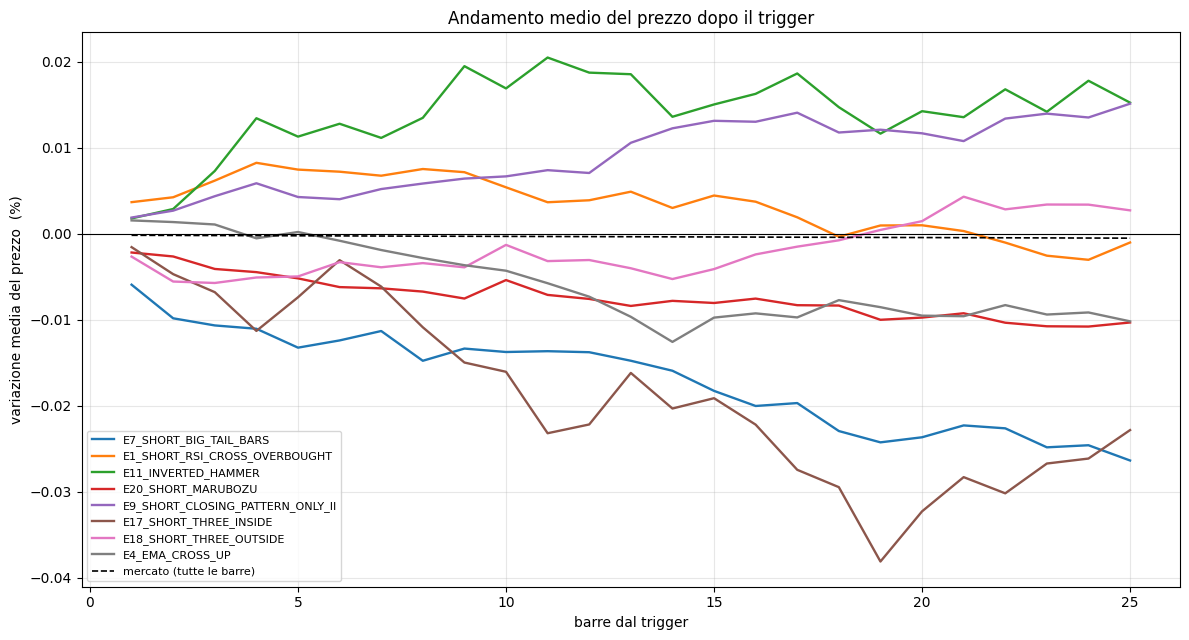

In [ ]:
# solo le entry vere: le metro sono un righello, non candidate
entry_candidate = [n for n in eng.registry.list_entries() if n not in NOMI_METRO]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()
#ev.plot_singola("E7_BIG_TAIL_BARS", pips=True)

## 1.2 · La sintesi
| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `barra_picco` / `barra_picco_netto` | dove la curva è più estrema, e dove si stacca di più dal mercato (usato da `diagnosi()`) |
| `picco_pct` / `picco_pips` | il valore a quel picco — **può essere negativo**: non è un errore, è un trade che perde |
| `incertezza_pct` | quanto balla la media a quel punto. Tiene conto dei trigger vicini: per le condizioni che scattano spesso è più larga |
| `volte_incertezza` | picco diviso incertezza |
| `oltre_rumore` | **la colonna da guardare per prima**: `True` se `volte_incertezza` supera la soglia stampata sotto il grafico |
| `a_fine_pct` | dove sta il prezzo a fine orizzonte: più basso del picco = il movimento è rientrato |
| `vs_mercato_pct` | quanto il trigger si stacca dal movimento che il mercato fa comunque — vicino a zero = è il respiro dell'asset, non il segnale |
| `picco_in_coda` | `True` = il picco netto cade nell'ultimo quarto della finestra, segno di deriva casuale |

**La soglia di rumore.** Provando 52 condizioni, la prima della classifica sembra buona anche su dati casuali, e in più per ognuna si sceglie la barra migliore dell'orizzonte. La riga sotto il grafico (`soglia di rumore per … entry × picco su … barre`) dice oltre quale `|volte_incertezza|` il risultato non è più spiegabile dal caso. Conta solo le prove di *questa* chiamata: è un pavimento, non un tetto.

La tabella è ordinata per ampiezza, non per solidità: guarda sempre `oltre_rumore`, `trades` e `picco_in_coda` prima di scegliere.

In [ ]:
ev.sintesi.round(4).sort_values('picco_pips', ascending=False).head(6)

,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda,oltre_rumore
2,E11_INVERTED_HAMMER,1,442,11,2.2593,0.0205,0.0078,2.6475,0.0153,0.0202,11,False,False
4,E9_SHORT_CLOSING_PATTERN_ONLY_II,-1,2087,25,1.6767,0.0152,0.0061,2.4802,0.0152,0.0156,25,True,False
13,E1_RSI_CROSS_OVERSOLD,1,1824,25,1.6330,0.0148,0.0079,1.8815,0.0148,0.0143,25,True,False
27,E7_BIG_TAIL_BARS,1,1061,25,1.2580,0.0114,0.0088,1.2886,0.0114,0.0109,25,True,False
28,E18_THREE_OUTSIDE,1,1279,22,1.0747,0.0098,0.0076,1.2848,0.0038,0.0093,22,True,False
30,E4_SHORT_EMA_CROSS_DOWN,-1,1284,24,0.9845,0.0089,0.0078,1.1404,0.0077,0.0094,24,True,False


### LONG side

In [ ]:
ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
2,E11_INVERTED_HAMMER,2.259293,0.020518,2.647491,False
13,E1_RSI_CROSS_OVERSOLD,1.632999,0.014801,1.881476,False
27,E7_BIG_TAIL_BARS,1.258023,0.011365,1.288552,False
28,E18_THREE_OUTSIDE,1.074672,0.009793,1.284835,False
32,E6_BACK_IN_STYLE,0.827157,0.007482,1.081583,False
41,E11_INVERTED_HAMMER_CONFIRMED,0.788157,0.007149,0.895098,False


In [ ]:
LONG_condition_scelta = "E11_INVERTED_HAMMER"

### SHORT side

In [ ]:
ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
4,E9_SHORT_CLOSING_PATTERN_ONLY_II,1.676659,0.015150,2.480203,False
30,E4_SHORT_EMA_CROSS_DOWN,0.984461,0.008908,1.140366,False
1,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.916683,0.008273,2.724314,False
11,E3_SHORT_INTRABAR_STRENGTH_FADE,0.426390,0.003853,1.966531,False
49,E10_SHORT_HANGING_MAN,0.338366,0.003051,0.702001,False
46,E13_SHORT_HARAMI,0.242505,0.002188,0.778840,False


In [ ]:
SHORT_condition_scelta = "E4_SHORT_EMA_CROSS_DOWN"

In [ ]:
ev.diagnosi()

orizzonte impostato          : 25 barre
picchi (netti) nell'ultimo quarto: 52% (27/52, oltre la barra 19)
|picco| / incertezza, mediana: 1.32
|picco| / incertezza, massimo: 2.88
soglia di rumore (52 entry × picco su 25 barre): 3.92  —  entry oltre: 0

I picchi si ammassano in fondo alla finestra: e' il
comportamento di una deriva casuale, non di un segnale.
Prova a rileggere con horizon=6
e guarda se la forma delle curve cambia.


# SESSIONE 2 · Le condizioni di uscita

Fin qui abbiamo **misurato** un segnale: nessun capitale, nessuna posizione, nessun costo. Da adesso costruiamo un **sistema**: si sceglie un ingresso e si cerca il modo di uscirne.

## 2.1 · Come vengono calcolati stop e target

Nessuna soglia scritta a mano: uno stop dello 0.15% è enorme su EURUSD e minuscolo su BTCUSD. Per ogni barra si misura quanto sarebbe andato in rosso e in verde un trade lì aperto e tenuto `n` barre; lo stop del trade che apri ora è il **percentile richiesto di quelle escursioni sulle ultime 500 occorrenze concluse** — si allarga da solo su un asset volatile, si stringe quando il mercato si calma. Il valore si fissa all'apertura e non cambia più.

> **Perché "concluse" e non "partite".** L'escursione di un trade aperto alla barra `i` si conosce solo alla `i+n`. Usare le ultime 500 partite userebbe prezzi futuri per uno stop deciso oggi — la finestra è quindi spostata indietro di `n` barre.


## 2.2 · Backtest con i trigger selezionati

Una riga per combinazione. `combinazione` si legge `L=<entry long> · S=<entry short>`
(`—` dove quel lato non ha ingresso). Sotto `min_trades` le righe spariscono: se una
combinazione attesa non c'è, controlla prima lì.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | **il numero che conta**: pips medi per trade al netto delle commissioni. Sopra zero o non se ne parla |
| `t_stat` | quanto `avg_trade_netto` si distingue da zero, rispetto a quanto ballano i trade |
| `oltre_rumore` | `True` se `t_stat` supera la soglia stampata sopra la tabella |
| `avg_trade` | lo stesso, lordo — serve solo a vedere quanto si mangiano i costi |
| `trades` | sotto il centinaio, qualunque numero è rumore |
| `sharpe`, `max_dd_pct`, `win_rate_pct`, `profit_factor` | contorno |

**La soglia di rumore.** La riga sopra la tabella (`soglia di rumore per … righe`) dice oltre quale `|t_stat|` la riga migliore non è più spiegabile dal caso, contando le righe di *questa* chiamata. È un pavimento, non un tetto.

**Cosa fai dopo:** scegli la combinazione con `avg_trade_netto` più alto e abbastanza
trade, e congelala. In una chiamata l'uscita è identica per tutte le righe: la tabella
dice *quale entry rende di più con QUESTA uscita*, non quale uscita è la migliore.
Per confrontare uscite diverse rilanci con altri valori.

La tabella è ordinata per `sharpe`, non per `avg_trade_netto`: leggila per colonna, non per posizione.

**TEST 1**

Condizioni di uscita: STOP LOSS, TAKE PROFIT

In [ ]:
es = run_exit_search_bt(df_is, entry_cols_long=[LONG_condition_scelta, None],
                        entry_cols_short=[SHORT_condition_scelta, None],
                        n_barre=H, perc_sl=90.0, perc_tp=0.0,
                        **costi,)
es.top(10)
#es.trades("L=E7_BIG_TAIL_BARS · S=E9_SHORT_CLOSING_PATTERN_ONLY_II")

1 combinazione/i (None, None, *) scartata/e: nessun ingresso.
segnali ignorati per soglia non calcolabile — E4_SHORT_EMA_CROSS_DOWN: 3


Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

3 combinazioni · n_barre=25 · coppie di uscita: ['—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 3 righe (Sidak, famiglia 5%): |t_stat| > 2.39  —  righe oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,t_stat,oltre_rumore,durata_media,durata_max
0,L=— · S=E4_SHORT_EMA_CROSS_DOWN | X=—,1133,1.314,0.057,-6.996,49.250,1.015,0.907,0.211,0.249,False,23.463,25
1,L=E11_INVERTED_HAMMER · S=— | X=—,404,0.422,0.036,-5.164,48.020,1.016,0.866,0.172,0.138,False,24.131,25
2,L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_D...,1384,-0.795,-0.032,-9.507,48.483,0.996,0.699,0.004,0.006,False,23.664,25


**TEST 2**

Condizioni di uscita: STOP LOSS, TAKE PROFIT, Regole meccaniche

In [ ]:
exit_da_provare = eng.registry.list_exit_pairs()
exit_list=[]
for i in exit_da_provare:
  exit_list.append(i[0])
exit_list

['EMA_CROSS', 'MACD_CROSS', 'NO_EXIT', 'RSI_EXTREME']

In [ ]:
es = run_exit_search_bt(df_is,
                        entry_cols_long=[LONG_condition_scelta],
                        entry_cols_short=[SHORT_condition_scelta],
                        n_barre=H,
                        exit_rule_pairs=[*exit_list],
                        perc_sl=90.0, perc_tp=0.0, **costi,
                        min_trades=30,)
es.top(10)

segnali ignorati per soglia non calcolabile — E4_SHORT_EMA_CROSS_DOWN: 3


Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

4 combinazioni · n_barre=25 · coppie di uscita: ['EMA_CROSS', 'MACD_CROSS', 'NO_EXIT', 'RSI_EXTREME'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 4 righe (Sidak, famiglia 5%): |t_stat| > 2.49  —  righe oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,avg_trade_netto,t_stat,oltre_rumore,durata_media,durata_max
0,L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_D...,1425,-0.360,-0.018,-8.921,56.140,0.998,0.718,0.023,0.039,False,17.189,25
1,L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_D...,1384,-0.795,-0.032,-9.507,48.483,0.996,0.699,0.004,0.006,False,23.664,25
2,L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_D...,1552,-4.215,-0.190,-11.072,41.559,0.966,0.453,-0.242,-0.393,False,17.110,25
3,L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_D...,1625,-12.343,-0.763,-13.658,35.138,0.857,-0.175,-0.870,-1.947,False,9.691,25


In [ ]:
es.top().iloc[2][0]
#es.top().iloc[2]["combinazione"] # Pandas 3.0

'L=E11_INVERTED_HAMMER · S=E4_SHORT_EMA_CROSS_DOWN | X=EMA_CROSS'

# SESSIONE 3

## 3.1 · La classifica

Baseline (nessun filtro) + una riga per filtro, ordinata per `t_guadagno`.

| colonna | cosa guardi |
|---|---|
| `t_guadagno` | **la colonna che decide**: i trade che il filtro TIENE battono quelli che SCARTA, e di quanto rispetto al rumore |
| `oltre_rumore` | `True` solo se `t_guadagno` supera la soglia stampata sopra la tabella |
| `guadagno_pips` | di quanto li battono, in pips — la dimensione economica |
| `esito` | `SCARTATA` · `CAMPIONE CORTO` · `DA VALUTARE` |
| `motivo` | quale criterio è caduto |
| `avg_trade_netto`, `t_stat`, `p_ev_neg` | il sistema filtrato preso da solo |

**La soglia di rumore.** Provando 17 filtri, il migliore dei 17 sembra buono anche su
dati casuali. La riga stampata sopra la tabella dice oltre quale `|t_guadagno|` il
risultato non è più spiegabile dal caso. Conta solo le prove di *questa* chiamata:
è un pavimento, non un tetto.

**Cosa fai dopo:** vanno a `due_meta` solo le righe che NON sono `SCARTATA`.
Se non ce n'è nessuna, la risposta è che questa famiglia di filtri non aggiunge
niente: si torna indietro, non si abbassa la soglia.

`guadagno_sharpe` resta in `fs.risultati` come riferimento. Non decide più —
è uno Sharpe di equity giornaliera, quindi dipende da quanti trade fai e da quanto
stai a mercato, non solo dalla qualità del vantaggio.

In [ ]:
filtri_da_provare = (eng.registry.list_filters(0) +
                     eng.registry.list_filters(1) +
                     eng.registry.list_filters(-1))

In [ ]:
fs = run_filter_search_bt(
    df_is,
    entry_long=LONG_condition_scelta,
    entry_short=SHORT_condition_scelta,
    exit_rule_pair=None,
    n_barre=H,
    filtri=filtri_da_provare,
    perc_sl=90.0, perc_tp=0.0, **costi, min_trades_giudizio=100,
    p_max=5.0, alpha=0.05
)
fs.top(10)

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/133697 [00:00<?, ?bar/s]

26 righe (baseline + 25 filtri/coppie) · n_barre=25 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 25 prove (Sidak, famiglia 5%): |t_guadagno| > 3.08  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,trades,avg_trade_netto,t_stat,p_ev_neg,guadagno_pips,t_guadagno,oltre_rumore,esito,motivo
0,VWAP_FAIR_VALUE,774,2.001,1.916,2.60,3.084,2.088,False,SCARTATA,|t| 2.09 < soglia rumore 3.08
1,F2_MID_VOLATILITY,1033,0.801,0.958,17.15,2.635,1.522,False,SCARTATA,|t| 1.52 < soglia rumore 3.08
2,F20_SESSION_ASIA,547,1.210,0.982,16.07,1.959,1.248,False,SCARTATA,|t| 1.25 < soglia rumore 3.08
3,OVERNIGHT_RETURN,614,1.514,1.307,9.67,1.857,1.204,False,SCARTATA,|t| 1.20 < soglia rumore 3.08
4,VWAP_GAP_WIDENING,181,2.635,1.468,7.00,2.268,1.113,False,SCARTATA,|t| 1.11 < soglia rumore 3.08
5,F6_VOLUME_ABOVE_AVG_50,852,0.794,0.741,23.76,1.387,0.980,False,SCARTATA,|t| 0.98 < soglia rumore 3.08
6,TREND_CONTEXT,1237,0.409,0.504,29.95,1.820,0.974,False,SCARTATA,|t| 0.97 < soglia rumore 3.08
7,F1_ADX_ABOVE,758,0.657,0.625,26.51,1.282,0.867,False,SCARTATA,|t| 0.87 < soglia rumore 3.08
8,VWAP_POSITION,1220,0.402,0.490,31.56,1.416,0.793,False,SCARTATA,|t| 0.79 < soglia rumore 3.08
9,F22_FAR_FROM_ROLLOVER,1156,0.103,0.121,45.51,1.151,0.791,False,SCARTATA,|t| 0.79 < soglia rumore 3.08


In [ ]:
fs.scheda()                      # la baseline
#fs.scheda("VWAP_SESSION_CLOSE")  # una riga filtrata


  SCHEDA STRATEGIA  —  1384 trade
  EV netto per trade          0.004 pips   (lordo 0.699)
     cuscinetto sui costi: regge 0.004 pips di attrito in piu' prima di azzerarsi
  EV in R multipli           -0.001 R
  t-stat                       0.01
  P(EV<0)                      49.1 %      soglie: <5% ok, <1% molto buono
  IC 95% dell'EV          [-1.455 , 1.477] pips
  win rate                     48.5 %      pareggio a 48.5%  (margine +0.0)
  reward:risk realizzato       1.06        profit factor 1.000
  max DD a trade chiusi       995.7 pips
     Monte Carlo shuffle: mediano 1098, 90° pct 1519, 99° pct 1948 pips
     solo long     321 trade   EV -0.345 pips   t -0.25
     solo short   1063 trade   EV +0.110 pips   t +0.13
  ESITO                   SCARTATA   (P(EV<0) 49.1% >= 5%)


{'n_trades': 1384,
 'ev_pips': 0.004334528647749605,
 'ev_lordo': 0.6994127026315957,
 'ev_R': -0.0010154042110061471,
 'net_pips': 5.998987648485453,
 'win_rate': 48.482658959537574,
 'wr_pareggio': 48.47169228840097,
 'margine_wr': 0.010966671136600326,
 'reward_risk': 1.0630598041638724,
 'profit_factor': 1.0004391705385112,
 't_stat': 0.005849125513656225,
 'p_ev_neg': 49.120000000000005,
 'ic_ev_lo': -1.4545373406840496,
 'ic_ev_hi': 1.476881094554118,
 'dd_chiusi_pips': 995.6508449657485,
 'dd_50': 1098.2128313639778,
 'dd_90': 1518.7293547558297,
 'dd_99': 1948.2531328571988,
 'n_long': 321,
 'ev_long': -0.3449517008485708,
 't_long': -0.24936954889329707,
 'n_short': 1063,
 'ev_short': 0.10981042673647877,
 't_short': 0.12621417321311312,
 'esito': 'SCARTATA',
 'motivo': 'P(EV<0) 49.1% >= 5%'}

In [ ]:
lista_etichette_filtri_dm = (fs.risultati
    .loc[fs.risultati['esito'].isin(['DA VALUTARE', 'CAMPIONE CORTO']), 'filtro']
    .to_list())
print(f"{len(lista_etichette_filtri_dm)} candidati: {lista_etichette_filtri_dm}")

0 candidati: []


## 3.2 · `due_meta` — il vantaggio regge su entrambe le metà?

Si spacca l'In-Sample a metà e si guarda se il filtro aggiunge in tutte e due
(Difesa C, Passo 5). Un filtro che funziona solo in una metà è rumore.

Entry, uscita, orizzonte, `t_guadagno` e soglia si leggono **da `fs`**: non è
possibile verificare per errore un setup diverso. Il resto (`perc_sl`, `perc_tp`,
costi) va ripassato identico alla cella che ha costruito `fs`.

**Due condizioni, per due ragioni diverse:**

1. **Stabilità** — `guadagno_pips` positivo in entrambe le metà.
2. **Significatività** — `t_guadagno` sopra soglia sull'**intero** In-Sample.

La significatività si giudica sull'intero perché con ~250 trade per metà il rumore
produce da solo oscillazioni enormi. Le metà servono a scoprire un **cambio di
segno**, non a misurare con precisione. Per questo un calo fra le due metà non è
di per sé una condanna: conta il segno.

| verdetto | quando |
|---|---|
| `regge` | positivo in entrambe **e** t sopra soglia |
| `giudizio sospeso` | come sopra, ma poche osservazioni in una metà |
| `non regge` | `motivo` dice quale condizione è caduta |
| `baseline` | riga di riferimento (`None` fra le etichette), non un verdetto |

**Cosa fai dopo:** all'Out-of-Sample vanno solo i `regge`. Se non ce n'è nessuno,
non si apre l'OOS.

In [ ]:
assert fs.n_barre == H
etichette = [None, *lista_etichette_filtri_dm]  # 2-3 nomi presi da fs.top(15), es. "TREND_CONTEXT", "F1_ADX_ABOVE"

In [ ]:
dm = due_meta(df_is, fs, etichette, perc_sl=90.0, perc_tp=0.0, **costi)
dm.tabella

metà 1: 66849 barre, dal 2020-01-02 22:00:00+00:00 al 2022-09-08 03:45:00+00:00
metà 2: 66849 barre, dal 2022-09-08 04:00:00+00:00 al 2025-05-16 14:15:00+00:00


Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/66848 [00:00<?, ?bar/s]

,filtro,filtro_long,filtro_short,trades_metà1,trades_metà2,guadagno_pips_metà1,guadagno_pips_metà2,t_guadagno_metà1,t_guadagno_metà2,t_guadagno_intero,...,sharpe_metà1,sharpe_metà2,guadagno_sharpe_metà1,guadagno_sharpe_metà2,guadagno_avg_trade_metà1,guadagno_avg_trade_metà2,pochi_trade_metà1,pochi_trade_metà2,verdetto,motivo
0,— baseline —,—,—,692,686,NaN,NaN,NaN,NaN,NaN,...,-0.034,-0.036,0.0,0.0,0.0,0.0,False,False,baseline,


In [ ]:
lista_etichette_filtri_oos = dm.tabella[dm.tabella['verdetto'] == 'regge']['filtro'].to_list()
lista_etichette_filtri_oos

[]



------------------------------------------------------------------------------------------------------------------------


------





# SESSIONE 4 · Out-of-Sample (Passo 6)

Qui si apre il tratto di dati mai guardato finora — sigillato fin dallo split di Sessione 3 (`df_is`, `df_oos`). Non è un altro giro di ricerca: è la verifica finale, **una volta sola**, sui candidati che in `due_meta` hanno verdetto `regge`.

**Perché una volta sola.** Ogni volta che si guarda l'Out-of-Sample e si cambia qualcosa — un parametro, la lista dei filtri, la soglia — quel tratto di dati smette di essere una verifica indipendente e diventa parte della ricerca stessa, esattamente come l'In-Sample. Se il risultato di questa cella non convince, la risposta non è "aggiustare e rilanciare": è tornare al Passo 5 con un'idea diversa, sapendo che questo OOS specifico non è più vergine.

**Setup ed entry non si ripassano: si leggono da `fs`.** Come `due_meta`, anche questa cella legge `entry_long`, `entry_short`, `exit_rule_pair`, `n_barre`, `min_trades` direttamente dagli attributi di `fs` — non è possibile testare per errore un setup diverso da quello che `fs.top()` e `dm.tabella` hanno già mostrato.

**Il resto va ripassato identico** alla cella che ha costruito `fs` e a quella di `due_meta`: `perc_sl`, `perc_tp`, `finestra`, `lag`, `spread`, `commission`, `cash`, `margin` — non sono salvati su `fs`, quindi vanno riscritti a mano uguali a sopra.

**I candidati** sono la lista `filtri_oos`, presa a mano da quali righe di `dm.tabella` hanno verdetto `regge` — va aggiornata qui se cambiano le promozioni.

**Come si legge `oos.risultati`:** stesse colonne di `fs.top()` — baseline + una riga per candidato.

| colonna | cosa guardi |
|---|---|
| `avg_trade_netto` | pips per trade sull'OOS, al netto dei costi |
| `t_guadagno` | deve avere **lo stesso segno** dell'In-Sample e un ordine di grandezza simile. Un ribaltamento di segno è la firma della selezione a posteriori |
| `esito` | come in Sessione 3 |
| `trades` | per forza più bassi: l'OOS è il 20% dei dati |

**Prima cosa da guardare, sempre: la riga baseline.** Se il setup congelato non
regge da solo su dati mai visti, il problema è a monte del filtro.

**Cosa fare dopo:** niente. Si legge il risultato, si registra il giudizio (nei materiali del progetto, non ricalcolando), e si passa oltre — in avanti verso il prossimo passo della roadmap, o indietro al Passo 5 con un'idea diversa se l'OOS non convince. Non si ritocca questa cella.

In [ ]:
# le etichette di dm.tabella vanno tradotte nei nomi registrati:
# per una coppia l'etichetta non è un filtro, sono i due membri che la compongono
_righe = fs.risultati[fs.risultati['filtro'].isin(lista_etichette_filtri_oos)]
filtri_oos = sorted({n for n in _righe[['filtro_long', 'filtro_short']]
                            .to_numpy().ravel() if n != '—'})
print(f"filtri_oos: {filtri_oos}")

oos = run_filter_search_bt(
    df_oos,
    entry_long=fs.entry_long,
    entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair,
    n_barre=fs.n_barre,
    filtri=filtri_oos,
    perc_sl=90.0, perc_tp=0.0, finestra=500, lag=1,
    **costi, cash=10_000.0, margin=1.0,
    min_trades=fs.min_trades,
)
oos.risultati

filtri_oos: []


Backtest.run:   0%|          | 0/33424 [00:00<?, ?bar/s]

1 righe (baseline + 1 filtri/coppie) · n_barre=25 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00001 · commission 0.00003 · margin 1.0
soglia di rumore per 1 prove (Sidak, famiglia 5%): |t_guadagno| > 1.96  —  conta solo le prove di questa chiamata, e' un pavimento


,filtro,filtro_long,filtro_short,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,...,guadagno_sharpe,guadagno_avg_trade,n_tenuti,n_scartati,guadagno_pips,t_guadagno,trade_nuovi,oltre_rumore,esito,motivo
0,— baseline —,—,—,341,2.807112,0.66676,-2.463015,50.146628,1.136268,1.691493,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False,—,


## 4.1 · Equity vs buy & hold (OOS)

**Attenzione a come si legge:** buy & hold pieno su EURUSD non è un
benchmark "neutro" — il cambio non ha una deriva strutturale di lungo
periodo come un indice o BTC, quindi il suo andamento qui riflette
soprattutto la direzione presa dal prezzo in *questo* tratto OOS, non
un'alternativa passiva razionale. Batterlo (o perderci) non è di per sé
la prova che conta — quella resta oos.risultati (t_guadagno sopra la baseline). Questo grafico è un controllo visivo in più, non il
verdetto.

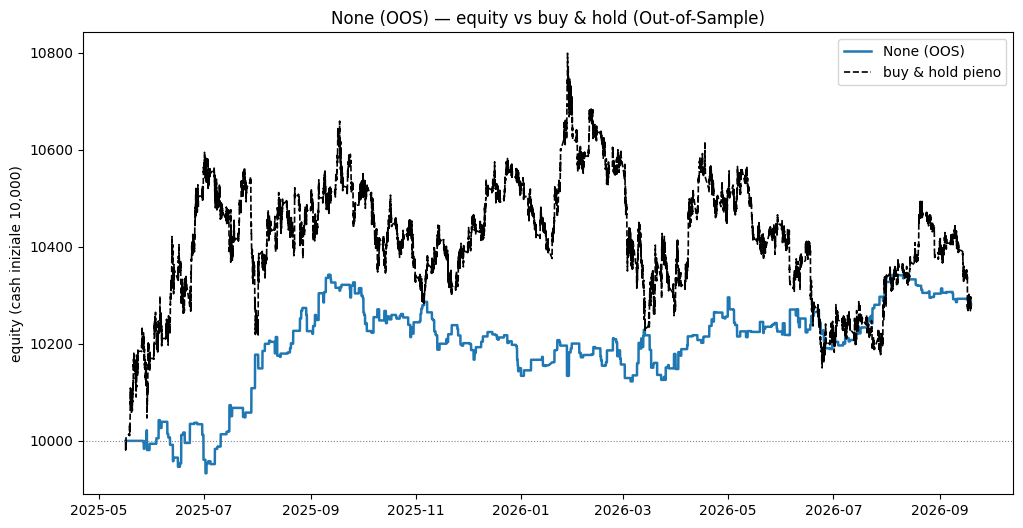

In [ ]:
for nome in [*lista_etichette_filtri_oos, None]:
    ax, curva = plot_equity(oos.trades(nome), df_oos, cash=10_000.0,
                            etichetta=f"{nome} (OOS)")